# 🔬 Data exploration and preparation
In this notebook, we'll examine the dataset and create a subset of it for further analysis. The dataset was relatively clean when downloaded, though we addressed some problematic delimiter issues for you. If you're interested in tackling these issues firsthand, the original dataset is available at the [Book-Crossing Dataset](http://www2.informatik.uni-freiburg.de/~cziegler/BX/).

In [12]:
# Import necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt


### 1. Loading the data
Load the three datasets and explore the data.


In [3]:
# Gets the current working directory
base_dir = os.getcwd() 
# Joins it with the data folder
data_dir = os.path.join(base_dir, 'data') 
# Load the dataset containing book information
df_books = pd.read_csv(os.path.join(data_dir, 'BX-Books.csv'), sep=';',
                       encoding='latin-1', low_memory=False)

# Load the dataset containing user information
df_users = pd.read_csv(os.path.join(data_dir, 'BX-Users.csv'), sep=';',
                       encoding='latin-1', low_memory=False)

# Load the dataset containing book ratings
df_ratings = pd.read_csv(os.path.join(data_dir, 'BX-Book-Ratings.csv'), sep=';',
                       encoding='latin-1', low_memory=False)

# Explore shape and first rows
print(df_books.shape)
df_books.head()


(271379, 8)


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [4]:
print(df_users.shape)
df_users.head()


(278858, 3)


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [5]:
print(df_ratings.shape)
df_ratings.head()


(1149779, 3)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


### 2. Cleaning the data
Ensure that all reviews are linked to a book. Investigate whether there are any reviews that lack a corresponding book or user. Verify the accuracy of author names and identify any anomalies, such as users who have submitted an unusually high number of reviews. Describe the process you followed to clean the data.

In [6]:
# Keep only ratings whose ISBN exists in the books dataset
df_ratings_clean = df_ratings[df_ratings['ISBN'].isin(df_books['ISBN'])]
df_ratings_clean.shape


(1031175, 3)

In [7]:
# Keep only ratings whose User-ID exists in the users dataset
df_ratings_clean = df_ratings_clean[df_ratings_clean['User-ID'].isin(df_users['User-ID'])]
df_ratings_clean.shape


(1031175, 3)

In [22]:
# Remove whitespace and standardize capitalization
df_books['Book-Author'] = df_books['Book-Author'].str.strip().str.title()

# Remove rows with missing or empty author names
df_books = df_books[df_books['Book-Author'].notna() & (df_books['Book-Author'] != "")]
df_books.shape


(271377, 8)

count    92107.000000
mean        11.195403
std         88.687288
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max      11144.000000
Name: review_count, dtype: float64


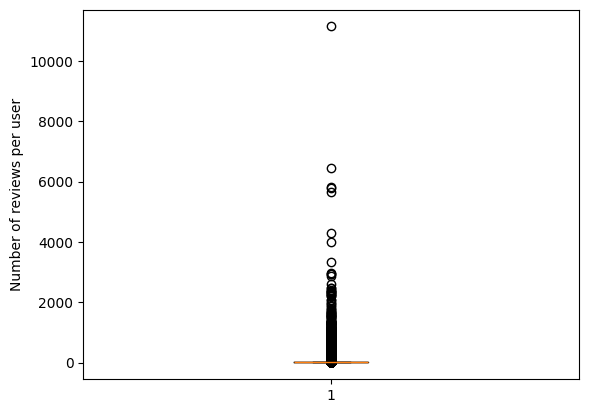

In [ ]:
# Count number of reviews per user
user_review_counts = (
    df_ratings_clean
    .groupby('User-ID')
    .size()
    .reset_index(name='review_count')
)

# Inspect distribution (high max!)
print(user_review_counts['review_count'].describe())

# Plot boxplot showing (extreme) outliers
plt.figure()
plt.boxplot(user_review_counts['review_count'])
plt.ylabel('Number of reviews per user')
plt.show()


### 3. Subsetting the data
The publication accompanied with this dataset [Improving Recommendation Lists Through Topic Diversification](http://www2.informatik.uni-freiburg.de/~cziegler/BX/WWW-2005-Preprint.pdf) by Cai-Nicolas Ziegler, Sean M. McNee, Joseph A. Konstan, Georg Lausen; describes the process of subsetting (condensation steps) the dataset as follows (p5): 

> Hence, we discarded all books missing taxonomic descriptions, along with all ratings referring to them. Next, we also removed book titles with fewer than 20 overall mentions. Only community members with at least five ratings each were kept. 

Investigate the significance of these parameters for the dataset as a whole. Additionally, decide whether to include implicit ratings (where Book-Rating equals 0) in your final dataset. Consider the potential consequences of this choice. Would you opt to exclude them prior to assessing other parameters, or would it be more appropriate to exclude them later?

Although the publication outlines the expected dimensions of the resulting dataset, it's acceptable if your findings vary at this stage.

In [20]:
# Remove implicit ratings
df_explicit = df_ratings[df_ratings['Book-Rating'] > 0]

# Apply book threshold
book_counts = df_explicit.groupby('ISBN').size()
valid_books = book_counts[book_counts >= 20].index

df_explicit = df_explicit[df_explicit['ISBN'].isin(valid_books)]

# Apply user threshold
user_counts = df_explicit.groupby('User-ID').size()
valid_users = user_counts[user_counts >= 5].index

df_explicit = df_explicit[df_explicit['User-ID'].isin(valid_users)]

# Check rows
df_explicit.shape


(56851, 3)

The original publication removes books without taxonomic descriptions because topic information is required for their diversification approach. However, the standard Book-Crossing dataset used here does not contain taxonomic metadata. Since the current study focuses on collaborative filtering rather than topic diversification, this condensation step is not applicable and was therefore omitted. 

The condensation thresholds significantly reduce sparsity in the user–item matrix. Removing books with fewer than 20 ratings eliminates items with insufficient collaborative signal, while restricting users to those with at least five ratings ensures reliable preference modeling. Excluding implicit ratings (rating = 0) prior to applying these thresholds results in a dataset based solely on explicit preference signals, improving the validity of similarity computations and recommendation quality.

### 4. Extra step
Examine the `BX-Books.csv` file specifically for the book Robots and _Empire by Isaac Asimov_. Identify any issues you come across. Would you address these issues?

Given that this could pose a problem for our dataset, consider how you would resolve it. You may need to revisit step 2 if you decide to undertake this additional step.

In [23]:
# Standardize book titles
df_books['Book-Title'] = df_books['Book-Title'].str.strip().str.title()


Inspection of Robots and Empire revealed multiple entries corresponding to different ISBNs and slight formatting inconsistencies. This leads to fragmented rating information and may weaken collaborative filtering signals. To mitigate this issue, book titles were standardized. Author names were already standardized. ISBN was retained as the primary item identifier to preserve dataset integrity, although merging duplicate editions could further improve recommendation quality.

### 5. Save the new dataset(s)
Save the dataset(s) in distinct named CSV-files for later usage. Move the file(s) to the data directory.


In [25]:
# Save filtered ratings
df_explicit.to_csv(
    os.path.join(data_dir, "BX-Ratings-Filtered.csv"),
    index=False
)

# Save corresponding books
df_books_filtered = df_books[df_books['ISBN'].isin(df_explicit['ISBN'])]

df_books_filtered.to_csv(
    os.path.join(data_dir, "BX-Books-Filtered.csv"),
    index=False
)

# Save corresponding users
df_users_filtered = df_users[df_users['User-ID'].isin(df_explicit['User-ID'])]

df_users_filtered.to_csv(
    os.path.join(data_dir, "BX-Users-Filtered.csv"),
    index=False
)
